**Capítulo 7**  
**7.5 Aplicação de Random Forest para previsão**<br>
**7.10 Aplicação de Gradient Boosting para previsão**<br>
**7.13 Aplicação de XGBOOST para previsão**<br>
**Base HAPPINESSALCOHOLCONSUMPTION.xlsx**

In [2]:
# Bibliotecas e funções necessárias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Divisão e validação de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance

# Métricas de avaliação
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error

# Suprimir alertas para manter a saída limpa
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Leitura da base de dados e definição de X (explicativas) e y (alvo contínuo)

cols_keep = ['Hemisphere', 'HappinessScore', 'HDI',
             'Beer_PerCapita', 'Spirit_PerCapita', 'logwine']

dados = pd.read_excel("HAPPINESSALCOHOLCONSUMPTION.xlsx", usecols=cols_keep)

dados['Hemisphere'].replace('noth', 'both', inplace=True)

# Visualizar as primeiras linhas
display(dados.head())

# Verificar tipos e estrutura
display(dados.info())

# Definir variável-alvo (y) e preditoras (X)
y = dados['HappinessScore']            # variável que queremos prever
X = dados.drop(columns='HappinessScore')  # restam as variáveis preditoras

,Hemisphere,HappinessScore,HDI,Beer_PerCapita,Spirit_PerCapita,logwine
0,north,7.526,928,224,81,2.444045
1,north,7.509,943,185,100,2.447158
2,north,7.501,933,233,61,1.892095
3,north,7.498,951,169,71,2.110590
4,north,7.413,918,263,133,1.986772


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Hemisphere        122 non-null    object 
 1   HappinessScore    122 non-null    float64
 2   HDI               122 non-null    int64  
 3   Beer_PerCapita    122 non-null    int64  
 4   Spirit_PerCapita  122 non-null    int64  
 5   logwine           122 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 5.8+ KB


None

In [4]:
# Transformação de variáveis categóricas em dummies

# Identificar variáveis categóricas (tipo 'object' ou 'category')
variaveis_categoricas = X.select_dtypes(include=['object', 'category']).columns

# Aplicar one-hot encoding (dummies), excluindo a primeira categoria para evitar multicolinearidade
X_dummies = pd.get_dummies(X, columns=variaveis_categoricas, drop_first=True)

# Verificar o novo shape da matriz X
print(f"Número de variáveis após criar dummies: {X_dummies.shape[1]}")
display(X_dummies)

Número de variáveis após criar dummies: 6


,HDI,Beer_PerCapita,Spirit_PerCapita,logwine,Hemisphere_north,Hemisphere_south
0,928,224,81,2.444045,True,False
1,943,185,100,2.447158,True,False
2,933,233,61,1.892095,True,False
3,951,169,71,2.110590,True,False
4,918,263,133,1.986772,True,False
...,...,...,...,...,...,...
117,533,36,6,0.000000,False,True
118,432,19,152,0.301030,True,False
119,512,34,4,1.113943,True,False
120,500,36,2,1.278754,True,False


In [5]:
# Separar base em treino e teste + configurar validação cruzada

# Separar base: 70% treino, 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    X_dummies, y, test_size=0.3, random_state=42
)

# Configurar validação cruzada (5-fold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Base de treino: {X_train.shape[0]} observações")
print(f"Base de teste: {X_test.shape[0]} observações")

Base de treino: 85 observações
Base de teste: 37 observações


In [6]:
# Modelo 1: Regressão linear múltipla

# Separaremos a base em 'treino' e 'teste' para fins de comparação da performance desse algoritmo com os demais.

from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr) * 100

print(f"R² na base de teste: {r2_lr:.4f}")
print(f"RMSE na base de teste: {rmse_lr:.4f}")
print(f"MAPE na base de teste (%): {mape_lr:.2f}")

R² na base de teste: 0.6147
RMSE na base de teste: 0.7287
MAPE na base de teste (%): 11.74


In [7]:
# Modelo 2: Árvore de Regressão com seleção de hiperparâmetros

from sklearn.tree import DecisionTreeRegressor

# Definir grade de hiperparâmetros
param_grid = {
    'max_depth': [2, 4, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Modelo base
arvore = DecisionTreeRegressor(random_state=42)

# Ajustar modelo com validação cruzada
grid_arvore = GridSearchCV(
    estimator=arvore,
    param_grid=param_grid,
    scoring='r2', # naturalmente, outra métrica poderia ser empregada (por exemplo, neg_root_mean_squared_error para RMSE)
    cv=5,
    n_jobs=-1
)

grid_arvore.fit(X_train, y_train)

# Melhor modelo encontrado
modelo_arvore_otimo = grid_arvore.best_estimator_

# Avaliar na base de teste
y_pred_arvore = modelo_arvore_otimo.predict(X_test)

r2_arvore = r2_score(y_test, y_pred_arvore)
rmse_arvore = root_mean_squared_error(y_test, y_pred_arvore)
mape_arvore = mean_absolute_percentage_error(y_test, y_pred_arvore) * 100

print("Melhores hiperparâmetros:", grid_arvore.best_params_)
print(f"R² na base de teste: {r2_arvore:.4f}")
print(f"RMSE na base de teste: {rmse_arvore:.4f}")
print(f"MAPE na base de teste (%): {mape_arvore:.2f}")

Melhores hiperparâmetros: {'max_depth': 2, 'min_samples_leaf': 4, 'min_samples_split': 2}
R² na base de teste: 0.5864
RMSE na base de teste: 0.7551
MAPE na base de teste (%): 10.71


In [8]:
# Modelo 3: Random Forest com busca de hiperparâmetros

from sklearn.ensemble import RandomForestRegressor

# Definir a grade de hiperparâmetros
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Modelo base
modelo_rf = RandomForestRegressor(random_state=42)

# Configurar a busca em grade com validação cruzada
grid = GridSearchCV(
    estimator=modelo_rf,
    param_grid=param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)

# Ajustar o modelo com os dados de treino
grid.fit(X_train, y_train)

# Exibir os melhores hiperparâmetros e desempenho
print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)

print(f"Melhor R² (validação cruzada): {grid.best_score_:.4f}")

# Armazenar o melhor modelo ajustado
modelo_otimo = grid.best_estimator_

resultados_grid = pd.DataFrame(grid.cv_results_)

tabela_resultados = resultados_grid[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values(by='mean_test_score', ascending=False)

tabela_resultados.rename(columns={
    'params': 'Hiperparâmetros',
    'mean_test_score': 'R² Médio (CV)',
    'std_test_score': 'Desvio Padrão',
    'rank_test_score': 'Ranking'
}, inplace=True)

# Exibir tabela
display(tabela_resultados.reset_index(drop=True))

# Fazer previsões na base de teste
y_pred_rf = modelo_otimo.predict(X_test)

# Calcular métricas de desempenho
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

print(f"R² na base de teste: {r2_rf:.4f}")
print(f"RMSE na base de teste: {rmse_rf:.4f}")
print(f"MAPE na base de teste (%): {mape_rf:.2f}")

Melhores hiperparâmetros encontrados:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Melhor R² (validação cruzada): 0.6806


,Hiperparâmetros,R² Médio (CV),Desvio Padrão,Ranking
0,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.680579,0.092108,1
1,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.680560,0.092109,2
2,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",0.680560,0.092109,2
3,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.678028,0.092983,4
4,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.676561,0.093714,5
5,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",0.676561,0.093714,5
6,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.675561,0.095463,7
7,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.675544,0.095561,8
8,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",0.675544,0.095561,8
9,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.670207,0.100535,10


R² na base de teste: 0.6905
RMSE na base de teste: 0.6532
MAPE na base de teste (%): 9.56


Melhores hiperparâmetros: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.6}
Top 10 variáveis mais importantes no modelo:


,Variável,Importância
0,HDI,0.822682
1,Beer_PerCapita,0.068519
3,logwine,0.065551
2,Spirit_PerCapita,0.038144
5,Hemisphere_south,0.003850
4,Hemisphere_north,0.001254


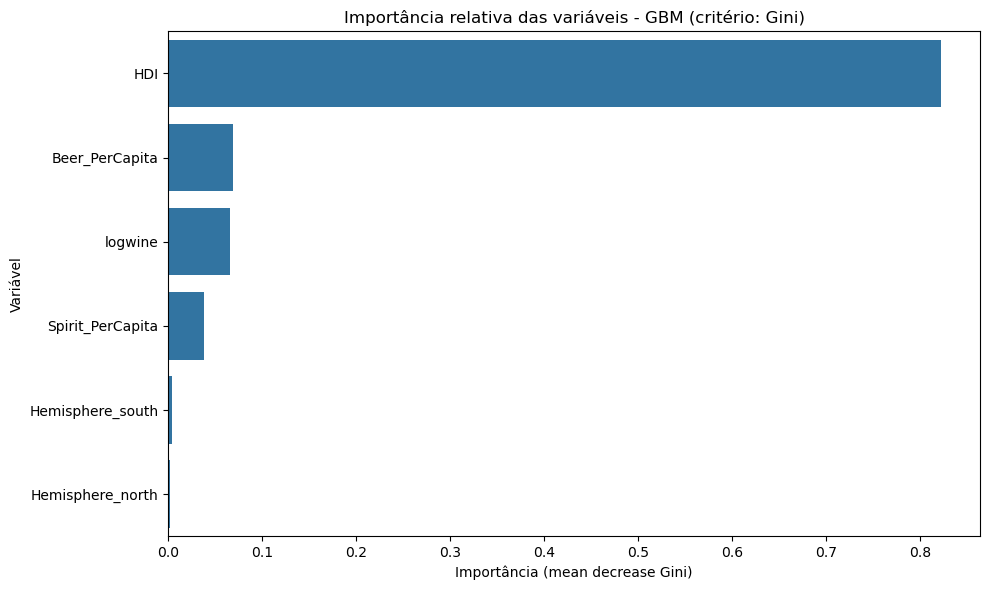

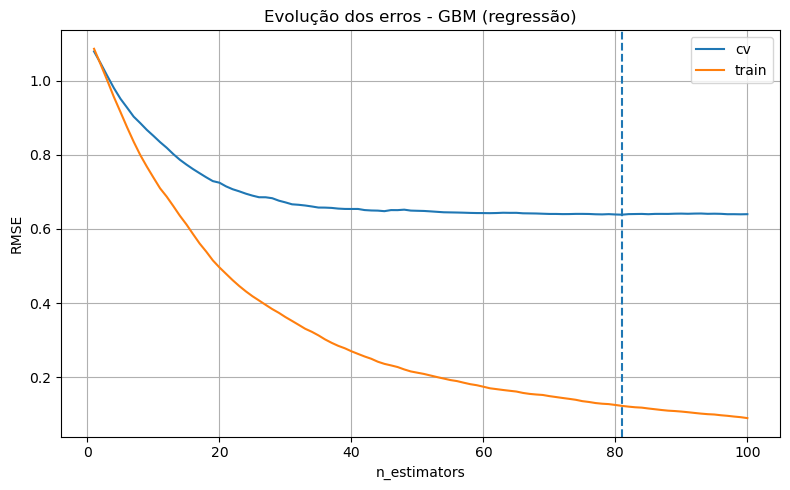

Melhor iteração (menor RMSE em CV): 81 de 100
R² na base de teste: 0.6939
RMSE na base de teste: 0.6496
MAPE na base de teste (%): 9.66


In [9]:
# Modelo 4: Gradient Boosting com pesquisa de hiperparâmetros

from sklearn.ensemble import GradientBoostingRegressor

# Definir grade de hiperparâmetros
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [1, 2, 5],
    'subsample': [0.6, 0.8, 1.0]
}

# Modelo base
gbm = GradientBoostingRegressor(random_state=42)

# Configurar GridSearchCV
grid_gbm = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_gbm.fit(X_train, y_train)

# Melhor modelo
modelo_gbm_otimo = grid_gbm.best_estimator_
modelo_final_gbm = grid.best_estimator_
print("Melhores hiperparâmetros:", grid_gbm.best_params_)

importancias = modelo_final_gbm.feature_importances_

df_importancia = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# Visualizar os 10 mais importantes
print("Top 10 variáveis mais importantes no modelo:")
display(df_importancia.head(10))

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia.head(15), x='Importância', y='Variável')
plt.title('Importância relativa das variáveis - GBM (critério: Gini)')
plt.xlabel('Importância (mean decrease Gini)')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

# Curvas de evolução dos erros
best = grid_gbm.best_params_.copy()
N_EST = int(best.get('n_estimators', 100))
best['n_estimators'] = N_EST
best.setdefault('random_state', 42)

# Curva de treino no X_train inteiro
gb_full = GradientBoostingRegressor(**best)
gb_full.fit(X_train, y_train)

rmse_train = []
for yhat in gb_full.staged_predict(X_train):
    rmse_train.append(root_mean_squared_error(y_train, yhat))
rmse_train = np.asarray(rmse_train)

# Curva média de validação (KFold) com os mesmos hiperparâmetros
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=42)
rmse_cv = np.zeros(N_EST, dtype=float)

for tr_idx, va_idx in cv.split(X_train, y_train):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    gb = GradientBoostingRegressor(**best)
    gb.fit(X_tr, y_tr)

    for i, (yhat_tr, yhat_va) in enumerate(zip(gb.staged_predict(X_tr), gb.staged_predict(X_va))):
        rmse_cv[i] += root_mean_squared_error(y_va, yhat_va)

rmse_cv /= k
best_iter = int(np.argmin(rmse_cv) + 1)

# Gráfico: RMSE vs número de árvores
iters = np.arange(1, N_EST + 1)
plt.figure(figsize=(8, 5))
plt.plot(iters, rmse_cv, label="cv")
plt.plot(iters, rmse_train, label="train")
plt.axvline(best_iter, linestyle="--")
plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.title("Evolução dos erros - GBM (regressão)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Melhor iteração (menor RMSE em CV): {best_iter} de {N_EST}")

# Reestimar no treino completo com o n_estimators ótimo
modelo_final_gbm = GradientBoostingRegressor(**{**best, "n_estimators": best_iter})
modelo_final_gbm.fit(X_train, y_train)

# Avaliar na base de teste
y_pred_gbm = modelo_final_gbm.predict(X_test)
r2_gbm = r2_score(y_test, y_pred_gbm)
rmse_gbm = root_mean_squared_error(y_test, y_pred_gbm)
mape_gbm = mean_absolute_percentage_error(y_test, y_pred_gbm) * 100

print(f"R² na base de teste: {r2_gbm:.4f}")
print(f"RMSE na base de teste: {rmse_gbm:.4f}")
print(f"MAPE na base de teste (%): {mape_gbm:.2f}")

# (opcional) importâncias
importancias = modelo_final_gbm.feature_importances_

Melhores hiperparâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 100, 'subsample': 0.6}


,Importância
HDI,0.421907
logwine,0.146973
Hemisphere_north,0.133517
Spirit_PerCapita,0.122048
Beer_PerCapita,0.096228
Hemisphere_south,0.079327


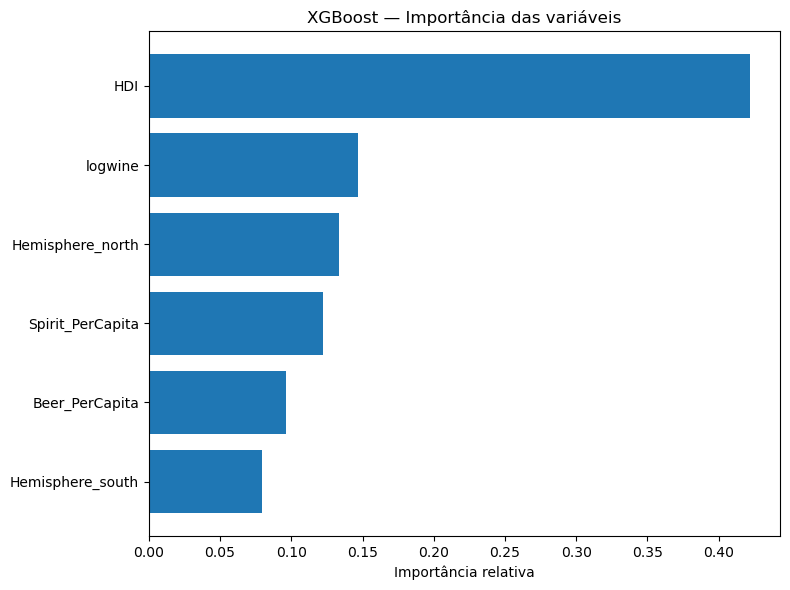

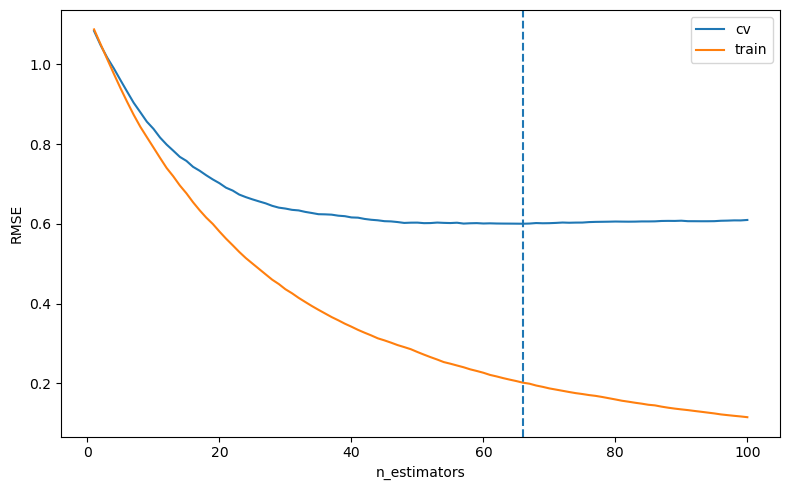

XGB | melhor n_estimators (CV): 66 de 100
R² na base de teste: 0.7035
RMSE na base de teste: 0.6393
MAPE na base de teste (%): 9.54


In [10]:
# Modelo 5: XGBoost com pesquisa de hiperparâmetros

from xgboost import XGBRegressor

# Definir grade de hiperparâmetros
param_grid = {
    'n_estimators': [100, 300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Instanciar modelo base
xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Configurar GridSearchCV
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=0
)

# Ajustar modelo
grid_xgb.fit(X_train, y_train)

# Melhor modelo encontrado
modelo_xgb_otimo = grid_xgb.best_estimator_
print("Melhores hiperparâmetros:", grid_xgb.best_params_)

# Importância (modelo do grid)
xgb_imp = (pd.Series(modelo_xgb_otimo.feature_importances_, index=X_train.columns)
             .sort_values(ascending=False))
display(xgb_imp.to_frame("Importância").head(15))

plt.figure(figsize=(8, 6))
plt.barh(xgb_imp.index, xgb_imp.values)
plt.gca().invert_yaxis()
plt.xlabel("Importância relativa")
plt.title("XGBoost — Importância das variáveis")
plt.tight_layout()
plt.show()

# Curva de erros
best = grid_xgb.best_params_.copy()
N_EST = int(best.get('n_estimators', 300))
best['n_estimators'] = N_EST
best.setdefault('random_state', 42)
best.setdefault('n_jobs', -1)
best.setdefault('eval_metric', 'rmse')

k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=42)
xgb_rmse_tr = np.zeros(N_EST, dtype=float)
xgb_rmse_cv = np.zeros(N_EST, dtype=float)

for tr_idx, va_idx in cv.split(X_train, y_train):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    xgb_tmp = XGBRegressor(**best)
    xgb_tmp.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=False)

    try:
        res = xgb_tmp.evals_result()
    except Exception:
        res = xgb_tmp.get_booster().evals_result()

    rmse_tr_fold = np.array(res['validation_0']['rmse'])
    rmse_va_fold = np.array(res['validation_1']['rmse'])

    m = min(N_EST, len(rmse_tr_fold), len(rmse_va_fold))
    xgb_rmse_tr[:m] += rmse_tr_fold[:m]
    xgb_rmse_cv[:m] += rmse_va_fold[:m]

xgb_rmse_tr /= k
xgb_rmse_cv /= k
m = np.count_nonzero(xgb_rmse_cv)
xgb_best_iter = int(np.argmin(xgb_rmse_cv[:m]) + 1)

# Gráfico RMSE vs n_estimators
iters = np.arange(1, m + 1)
plt.figure(figsize=(8, 5))
plt.plot(iters, xgb_rmse_cv[:m], label="cv")
plt.plot(iters, xgb_rmse_tr[:m], label="train")
plt.axvline(xgb_best_iter, linestyle="--")
plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()
print(f"XGB | melhor n_estimators (CV): {xgb_best_iter} de {N_EST}")

# Modelo final com o n_estimators ótimo
modelo_final_xgb = XGBRegressor(**{**best, "n_estimators": xgb_best_iter})
modelo_final_xgb.fit(X_train, y_train)

# Métricas no teste
y_pred_xgb_final = modelo_final_xgb.predict(X_test)

r2_xgb_final = r2_score(y_test, y_pred_xgb_final)
rmse_xgb_final = root_mean_squared_error(y_test, y_pred_xgb_final)
mape_xgb_final = mean_absolute_percentage_error(y_test, y_pred_xgb_final) * 100

print(f"R² na base de teste: {r2_xgb_final:.4f}")
print(f"RMSE na base de teste: {rmse_xgb_final:.4f}")
print(f"MAPE na base de teste (%): {mape_xgb_final:.2f}")

In [11]:
# Comparação dos Modelos: R² e RMSE na base de teste

comparacao_modelos = pd.DataFrame({
    'Modelo': [
        'Regressão Linear',
        'Árvore de Regressão',
        'Random Forest',
        'Gradient Boosting (GBM)',
        'XGBoost'
    ],
    'R²': [
        r2_lr,
        r2_arvore,
        r2_rf,
        r2_gbm,
        r2_xgb_final
    ],
    'RMSE': [
        rmse_lr,
        rmse_arvore,
        rmse_rf,
        rmse_gbm,
        rmse_xgb_final
    ],
    'MAPE': [
        mape_lr,
        mape_arvore,
        mape_rf,
        mape_gbm,
        mape_xgb_final
    ]
})

# Ordenar pela performance (R² decrescente)
comparacao_modelos = comparacao_modelos.sort_values(by='R²', ascending=False).reset_index(drop=True)

display(comparacao_modelos.style.format({'R²': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE': '{:.2f}'}))

,Modelo,R²,RMSE,MAPE
0,XGBoost,0.7035,0.6393,9.54
1,Gradient Boosting (GBM),0.6939,0.6496,9.66
2,Random Forest,0.6905,0.6532,9.56
3,Regressão Linear,0.6147,0.7287,11.74
4,Árvore de Regressão,0.5864,0.7551,10.71
